E-COMMERCE STORE ANALYSIS REPORT

1. CUSTOMER REPEAT ANALYSIS
Total customers in database: 500
Customers who have placed orders: 498
Repeat customers (more than 1 order): 485
Percentage of customers repeating: 97.00%

Top 10 Most Frequent Customers:
----------------------------------------
C0028 - Crystal: 13 orders
C0113 - Ryan: 13 orders
C0243 - Margaret: 12 orders
C0475 - Brooke: 11 orders
C0108 - William: 11 orders
C0268 - Gary: 11 orders
C0406 - Kirsten: 11 orders
C0220 - Joshua: 11 orders
C0338 - James: 11 orders
C0414 - Rachel: 10 orders

2. TOP SELLING PRODUCTS
Top 5 Best Selling Products:
------------------------------------------------------------
                                     quantity    revenue  order_count
product_id product_name category                                     
P041       Behind       Footwear          123   57240.51           39
P097       Away         Home              117  109097.82           33
P091       Foot         Clothing          115   18121.

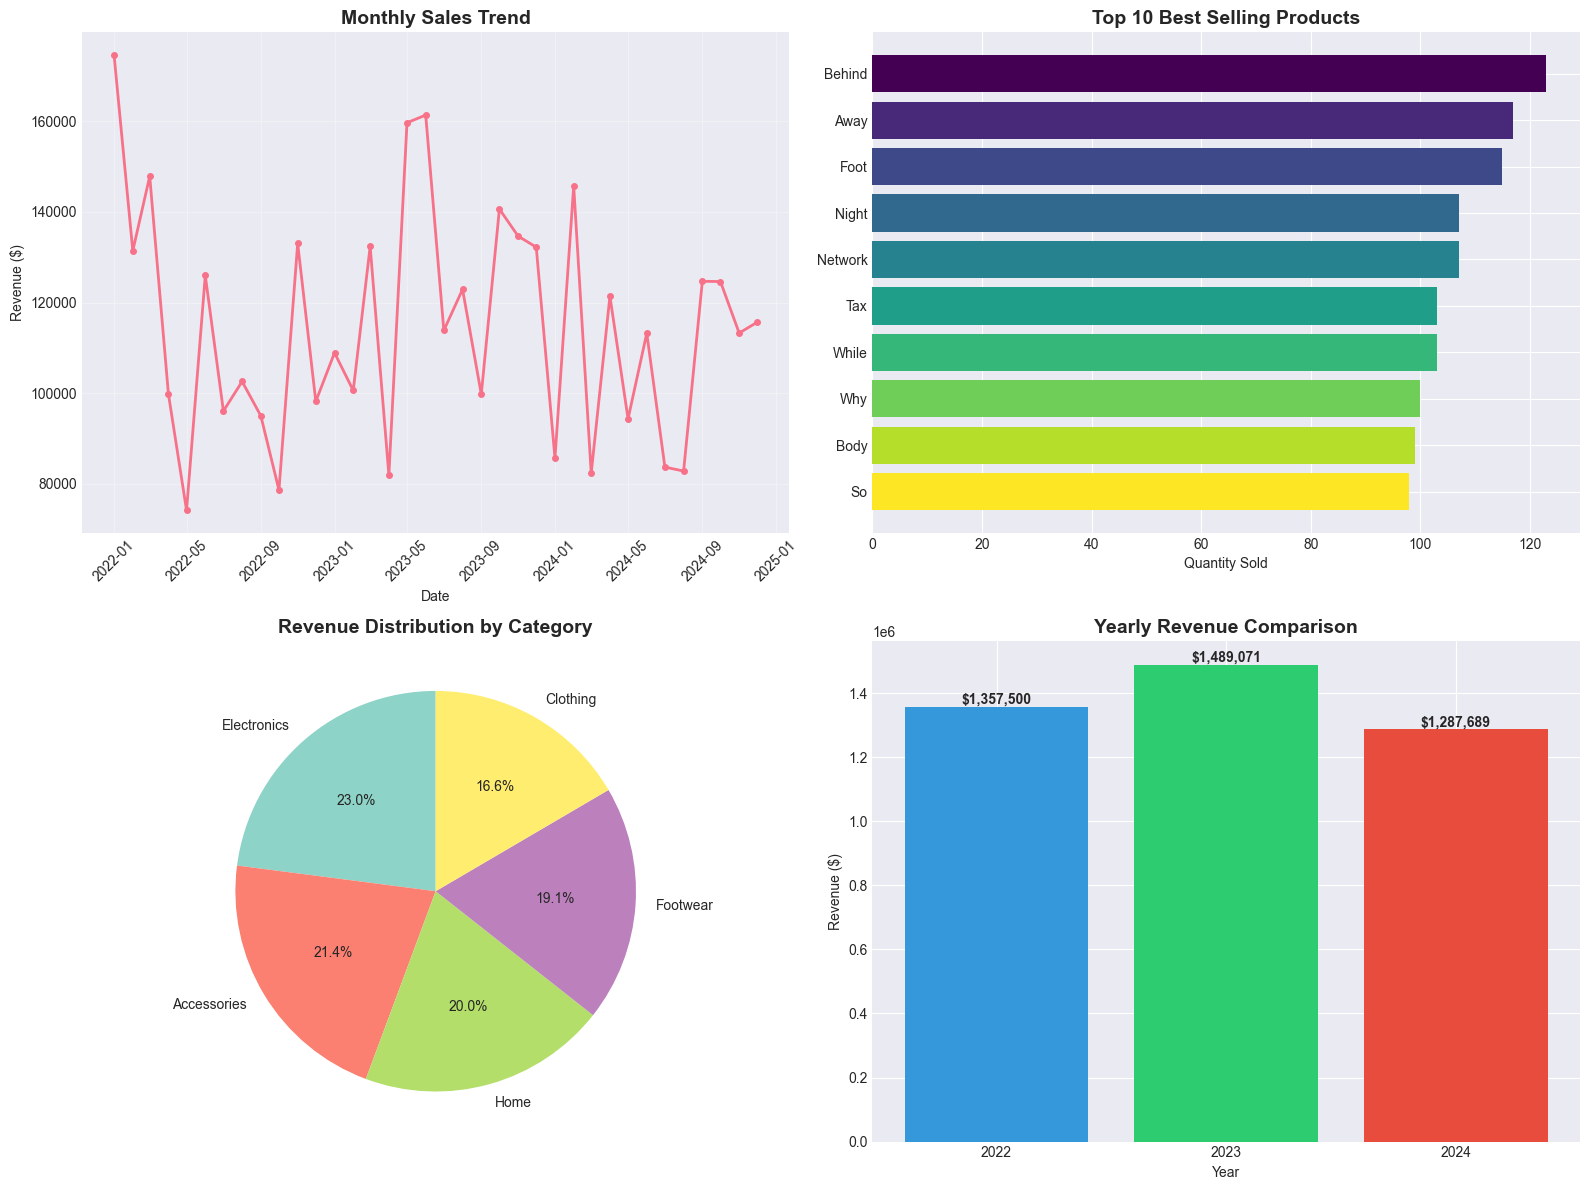

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Read the CSV files
customers_df = pd.read_csv('customers.csv')
orders_df = pd.read_csv('orders.csv')
products_df = pd.read_csv('products.csv')
students_df = pd.read_csv('students_five_classes.csv')

# Display basic information about the datasets
print("=" * 80)
print("E-COMMERCE STORE ANALYSIS REPORT")
print("=" * 80)

# ============================================================================
# 1. CUSTOMER REPEAT ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("1. CUSTOMER REPEAT ANALYSIS")
print("=" * 80)

# Count orders per customer
customer_order_counts = orders_df['customer_id'].value_counts()
repeat_customers = customer_order_counts[customer_order_counts > 1]
total_customers = len(customers_df)

print(f"Total customers in database: {total_customers}")
print(f"Customers who have placed orders: {len(orders_df['customer_id'].unique())}")
print(f"Repeat customers (more than 1 order): {len(repeat_customers)}")
print(f"Percentage of customers repeating: {(len(repeat_customers)/total_customers)*100:.2f}%")

print("\nTop 10 Most Frequent Customers:")
print("-" * 40)
top_customers = customer_order_counts.head(10)
for customer_id, order_count in top_customers.items():
    customer_name = customers_df[customers_df['customer_id'] == customer_id]['name'].values
    if len(customer_name) > 0:
        print(f"{customer_id} - {customer_name[0]}: {order_count} orders")

# ============================================================================
# 2. TOP SELLING PRODUCT (BASED ON TOTAL QUANTITY)
# ============================================================================
print("\n" + "=" * 80)
print("2. TOP SELLING PRODUCTS")
print("=" * 80)

# Merge orders with products to get product details
orders_with_products = orders_df.merge(products_df, on='product_id', how='left')
orders_with_products['revenue'] = orders_with_products['quantity'] * orders_with_products['price']

# Calculate total quantity sold per product
product_sales = orders_with_products.groupby(['product_id', 'product_name', 'category']).agg({
    'quantity': 'sum',
    'revenue': 'sum',
    'order_id': 'count'  # Number of times ordered
}).rename(columns={'order_id': 'order_count'}).sort_values('quantity', ascending=False)

print("Top 5 Best Selling Products:")
print("-" * 60)
print(product_sales.head(10).to_string())

# Get the absolute top seller
top_product = product_sales.iloc[0]
print(f"\n TOP SELLING PRODUCT: {top_product.name[1]} (ID: {top_product.name[0]})")
print(f"   Category: {top_product.name[2]}")
print(f"   Total Quantity Sold: {int(top_product['quantity'])} units")
print(f"   Number of Orders: {int(top_product['order_count'])}")
print(f"   Total Revenue: ${top_product['revenue']:.2f}")

# ============================================================================
# 3. LEAST SOLD PRODUCT (TO DISCONTINUE)
# ============================================================================
print("\n" + "=" * 80)
print("3. PRODUCTS TO CONSIDER DISCONTINUING")
print("=" * 80)

# Find products with low sales
least_sold = product_sales[product_sales['quantity'] > 0].sort_values('quantity')

print("Bottom 5 Products (Lowest Sales):")
print("-" * 60)
print(least_sold.head(10).to_string())

worst_product = least_sold.iloc[0]
print(f"\n    LEAST SOLD PRODUCT: {worst_product.name[1]} (ID: {worst_product.name[0]})")
print(f"   Category: {worst_product.name[2]}")
print(f"   Total Quantity Sold: {int(worst_product['quantity'])} units")
print(f"   Number of Orders: {int(worst_product['order_count'])}")
print(f"   Total Revenue: ${worst_product['revenue']:.2f}")
print(f"\n RECOMMENDATION: Consider discontinuing {worst_product.name[1]}")

# Also check products that never sold
all_products = set(products_df['product_id'])
sold_products = set(orders_df['product_id'].unique())
unsold_products = all_products - sold_products

if unsold_products:
    print(f"\nProducts with ZERO sales: {len(unsold_products)} products")
    unsold_details = products_df[products_df['product_id'].isin(unsold_products)]
    print(unsold_details[['product_id', 'product_name', 'category', 'price']].to_string(index=False))

# ============================================================================
# 4. CUSTOMERS WHO NEED MORE DISCOUNTS (FREQUENT VISITORS)
# ============================================================================
print("\n" + "=" * 80)
print("4. FREQUENT CUSTOMERS FOR DISCOUNT PROGRAMS")
print("=" * 80)

# Find customers with more than 5 orders
frequent_customers = customer_order_counts[customer_order_counts >= 5].sort_values(ascending=False)

print(f"Customers who visited 5+ times: {len(frequent_customers)}")
print("\nVIP Customers (5+ orders):")
print("-" * 60)

vip_list = []
for customer_id, order_count in frequent_customers.items():
    customer_info = customers_df[customers_df['customer_id'] == customer_id].iloc[0]
    
    # Calculate total spent by this customer
    customer_orders = orders_df[orders_df['customer_id'] == customer_id]
    customer_revenue = 0
    for _, order in customer_orders.iterrows():
        product_price = products_df[products_df['product_id'] == order['product_id']]['price'].values
        if len(product_price) > 0:
            customer_revenue += order['quantity'] * product_price[0]
    
    vip_list.append({
        'customer_id': customer_id,
        'name': customer_info['name'],
        'city': customer_info['city'],
        'orders': order_count,
        'total_spent': customer_revenue
    })
    
    print(f"{customer_id} - {customer_info['name']} ({customer_info['city']}): {order_count} orders (${customer_revenue:.2f} spent)")

# Convert to DataFrame for better analysis
vip_df = pd.DataFrame(vip_list)
print(f"\nTotal revenue from VIP customers: ${vip_df['total_spent'].sum():.2f}")

# ============================================================================
# 5. TOTAL INCOME
# ============================================================================
print("\n" + "=" * 80)
print("5. TOTAL INCOME REPORT")
print("=" * 80)

total_revenue = orders_with_products['revenue'].sum()
print(f" TOTAL INCOME (All Time): ${total_revenue:,.2f}")

# Revenue by category
category_revenue = orders_with_products.groupby('category')['revenue'].sum().sort_values(ascending=False)
print("\nRevenue by Category:")
print("-" * 40)
for category, revenue in category_revenue.items():
    percentage = (revenue / total_revenue) * 100
    print(f"{category}: ${revenue:,.2f} ({percentage:.1f}%)")

# ============================================================================
# 6. YEARLY SALES REPORT
# ============================================================================
print("\n" + "=" * 80)
print("6. YEARLY SALES REPORT")
print("=" * 80)

# Convert order_date to datetime
orders_with_products['order_date'] = pd.to_datetime(orders_with_products['order_date'])
orders_with_products['year'] = orders_with_products['order_date'].dt.year
orders_with_products['month'] = orders_with_products['order_date'].dt.month
orders_with_products['year_month'] = orders_with_products['order_date'].dt.to_period('M')

yearly_sales = orders_with_products.groupby('year').agg({
    'revenue': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'order_count'})

print("Yearly Sales Summary:")
print("-" * 60)
for year, row in yearly_sales.iterrows():
    print(f"{year}: ${row['revenue']:,.2f} from {int(row['order_count'])} orders")

# Calculate year-over-year growth
years = sorted(yearly_sales.index)
if len(years) >= 2:
    print("\nYear-over-Year Growth:")
    for i in range(1, len(years)):
        prev_year = years[i-1]
        curr_year = years[i]
        growth = ((yearly_sales.loc[curr_year, 'revenue'] - yearly_sales.loc[prev_year, 'revenue']) / 
                 yearly_sales.loc[prev_year, 'revenue']) * 100
        print(f"{curr_year} vs {prev_year}: {growth:.2f}% growth")

# ============================================================================
# 7. MONTHLY SALES REPORT
# ============================================================================
print("\n" + "=" * 80)
print("7. MONTHLY SALES REPORT")
print("=" * 80)

monthly_sales = orders_with_products.groupby(['year', 'month']).agg({
    'revenue': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'order_count'}).sort_values(['year', 'month'])

print("Monthly Sales Breakdown:")
print("-" * 80)
print(f"{'Year':<6} {'Month':<10} {'Orders':<10} {'Revenue':<15}")
print("-" * 80)

for (year, month), row in monthly_sales.iterrows():
    month_name = datetime(2000, month, 1).strftime('%B')
    print(f"{year:<6} {month_name:<10} {int(row['order_count']):<10} ${row['revenue']:>12,.2f}")

# Find best and worst months
best_month = monthly_sales.loc[monthly_sales['revenue'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales[monthly_sales['revenue'] > 0]['revenue'].idxmin()]

print(f"\n Best Month: {int(best_month.name[0])} {datetime(2000, int(best_month.name[1]), 1).strftime('%B')} - ${best_month['revenue']:,.2f}")
print(f" Worst Month: {int(worst_month.name[0])} {datetime(2000, int(worst_month.name[1]), 1).strftime('%B')} - ${worst_month['revenue']:,.2f}")

# ============================================================================
# 8. ADDITIONAL INSIGHTS
# ============================================================================
print("\n" + "=" * 80)
print("8. ADDITIONAL INSIGHTS")
print("=" * 80)

# Average Order Value
avg_order_value = orders_with_products.groupby('order_id')['revenue'].sum().mean()
print(f"Average Order Value: ${avg_order_value:.2f}")

# Most popular category
popular_category = orders_with_products['category'].value_counts()
print(f"\nMost Popular Category: {popular_category.index[0]} ({popular_category.iloc[0]} orders)")

# Customer demographics
print("\nCustomer Demographics:")
print(f"Male Customers: {len(customers_df[customers_df['gender'] == 'Male'])}")
print(f"Female Customers: {len(customers_df[customers_df['gender'] == 'Female'])}")
print(f"Average Age: {customers_df['age'].mean():.1f} years")

# Top cities by customer count
top_cities = customers_df['city'].value_counts().head(5)
print("\nTop 5 Cities by Customer Count:")
for city, count in top_cities.items():
    print(f"  {city}: {count} customers")

# ============================================================================
# 9. VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("9. GENERATING VISUALIZATIONS")
print("=" * 80)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Monthly Sales Trend
ax1 = plt.subplot(2, 2, 1)
monthly_trend = monthly_sales.reset_index()
monthly_trend['date'] = pd.to_datetime(monthly_trend['year'].astype(str) + '-' + monthly_trend['month'].astype(str) + '-01')
monthly_trend = monthly_trend.sort_values('date')
ax1.plot(monthly_trend['date'], monthly_trend['revenue'], marker='o', linewidth=2, markersize=4)
ax1.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Top 10 Products
ax2 = plt.subplot(2, 2, 2)
top_10_products = product_sales.head(10).reset_index()
colors = plt.cm.viridis(np.linspace(0, 1, 10))
bars = ax2.barh(range(len(top_10_products)), top_10_products['quantity'], color=colors)
ax2.set_yticks(range(len(top_10_products)))
ax2.set_yticklabels([f"{p[:15]}..." if len(p) > 15 else p for p in top_10_products['product_name']])
ax2.set_xlabel('Quantity Sold')
ax2.set_title('Top 10 Best Selling Products', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

# 3. Revenue by Category
ax3 = plt.subplot(2, 2, 3)
colors = plt.cm.Set3(np.linspace(0, 1, len(category_revenue)))
wedges, texts, autotexts = ax3.pie(category_revenue.values, 
                                     labels=category_revenue.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90)
ax3.set_title('Revenue Distribution by Category', fontsize=14, fontweight='bold')

# 4. Yearly Comparison
ax4 = plt.subplot(2, 2, 4)
years_data = yearly_sales.reset_index()
bars = ax4.bar(years_data['year'].astype(str), years_data['revenue'], color=['#3498db', '#2ecc71', '#e74c3c'])
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue ($)')
ax4.set_title('Yearly Revenue Comparison', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('ecommerce_analysis_report.png', dpi=300, bbox_inches='tight')
print(" Visualization saved as 'ecommerce_analysis_report.png'")

# ============================================================================
# 10. EXPORT REPORTS TO CSV
# ============================================================================
print("\n" + "=" * 80)
print("10. EXPORTING REPORTS TO CSV")
print("=" * 80)

# Export various reports
product_sales.to_csv('product_sales_report.csv')
monthly_sales.to_csv('monthly_sales_report.csv')
yearly_sales.to_csv('yearly_sales_report.csv')
vip_df.to_csv('vip_customers_report.csv', index=False)

print(" Reports exported:")
print("   - product_sales_report.csv")
print("   - monthly_sales_report.csv")
print("   - yearly_sales_report.csv")
print("   - vip_customers_report.csv")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)